In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\harsh\Downloads\archive (2)\PS_20174392719_1491204439457_log.csv",
    nrows=100000
)

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.isnull().sum()
df['isFlaggedFraud'].value_counts()

isFlaggedFraud
0    100000
Name: count, dtype: int64

In [5]:
df.drop(['isFlaggedFraud', 'nameOrig', 'nameDest'],  axis=1, inplace=True, errors='ignore')

In [6]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0


In [7]:
df.duplicated().sum()

np.int64(7)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df['isFraud'].value_counts()

isFraud
0    99877
1      116
Name: count, dtype: int64

In [11]:
df['type'].value_counts()

type
PAYMENT     39505
CASH_OUT    30718
CASH_IN     20185
TRANSFER     8597
DEBIT         988
Name: count, dtype: int64

In [12]:
pd.crosstab(df['type'], df['isFraud'])

isFraud,0,1
type,,
CASH_IN,20185,0
CASH_OUT,30659,59
DEBIT,988,0
PAYMENT,39505,0
TRANSFER,8540,57


In [13]:
fraud_rate=pd.crosstab(
               df['type'],
               df['isFraud'],
               normalize='index'
              )*100

fraud_rate

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.807930,0.192070
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.336978,0.663022


In [14]:
df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,99877.0,173186.629554,3.403175e+05,0.32,9956.6,52765.810,211736.240,6419835.27
1,116.0,541578.424138,1.535067e+06,164.00,17246.0,39077.815,296154.595,10000000.00


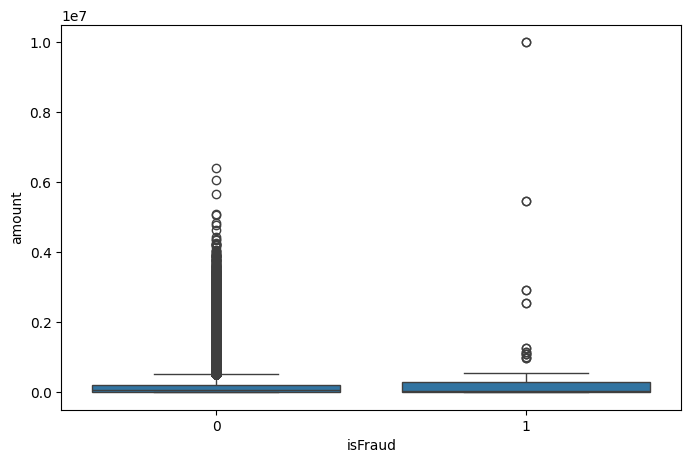

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x='isFraud',
    y='amount',
    data=df
)

plt.show()

In [16]:
df.corr(numeric_only=True)['isFraud'].sort_values(ascending=False)

isFraud           1.000000
amount            0.036421
oldbalanceOrg    -0.004144
newbalanceDest   -0.006396
oldbalanceDest   -0.009267
newbalanceOrig   -0.010873
step             -0.051330
Name: isFraud, dtype: float64

In [17]:
df=pd.get_dummies(
           df,
           columns=['type'],
           drop_first=True,
           dtype=int
          )

In [18]:
x=df.drop('isFraud', axis=1)
y=df['isFraud']

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(x, y, test_size=0.2, random_state=42)

In [20]:
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(79994, 10)
(79994,)
(19999, 10)
(19999,)


In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [22]:
df.dtypes

step                int64
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
type_CASH_OUT       int64
type_DEBIT          int64
type_PAYMENT        int64
type_TRANSFER       int64
dtype: object

In [46]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, Y_train)
Y_pred=lr.predict(X_test_scaled)
print(Y_pred)

[0 0 1 ... 1 0 0]


In [47]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("accuracy:", accuracy_score(Y_test, Y_pred))
print("f-1 score:", f1_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))

accuracy: 0.920046002300115
f-1 score: 0.02796352583586626
Recall: 0.9583333333333334


In [48]:
y_prob = lr.predict_proba(X_test_scaled)[:,1]
print(y_prob)

[1.06978460e-03 5.27010639e-08 5.98832826e-01 ... 9.16605577e-01
 2.69958683e-01 3.10393290e-08]


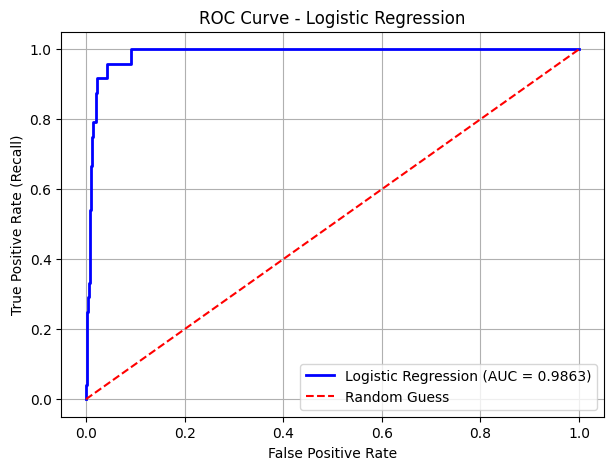

AUC Score : 0.9863308302044222


In [51]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
Y_prob=lr.predict_proba(X_test_scaled)[:,1]
fpr, tpr, thresholds=roc_curve(Y_test, Y_prob)
auc_score=roc_auc_score(Y_test, Y_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label=f'Logistic Regression (AUC = {auc_score:.4f})')


plt.plot([0,1],[0,1],'r--',label='Random Guess')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

print("AUC Score :", auc_score)

In [55]:
from sklearn.tree import DecisionTreeClassifier
cl=DecisionTreeClassifier(random_state=42)
cl.fit(X_train_scaled, Y_train)
y_pred=cl.predict(X_test_scaled)
print("accuracy:", accuracy_score(Y_test, y_pred))

accuracy: 0.9988499424971249


In [56]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(Y_test, y_pred))

[[19963    12]
 [   11    13]]


In [59]:
from sklearn.metrics import classification_report
report=classification_report(Y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19975
           1       0.52      0.54      0.53        24

    accuracy                           1.00     19999
   macro avg       0.76      0.77      0.77     19999
weighted avg       1.00      1.00      1.00     19999



In [62]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train_scaled, Y_train)
predictions=rf.predict(X_test_scaled)
print("Accuracy:", accuracy_score(Y_test, predictions))

Accuracy: 0.9993999699984999


In [64]:
print(confusion_matrix(Y_test, predictions))

[[19975     0]
 [   12    12]]


In [65]:
print(classification_report(Y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19975
           1       1.00      0.50      0.67        24

    accuracy                           1.00     19999
   macro avg       1.00      0.75      0.83     19999
weighted avg       1.00      1.00      1.00     19999



In [66]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance = importance.sort_values(ascending=False)

print(importance)

step              0.176805
oldbalanceOrg     0.153348
newbalanceOrig    0.151948
oldbalanceDest    0.125922
type_PAYMENT      0.121746
amount            0.084093
type_TRANSFER     0.071317
newbalanceDest    0.068455
type_CASH_OUT     0.045509
type_DEBIT        0.000856
dtype: float64


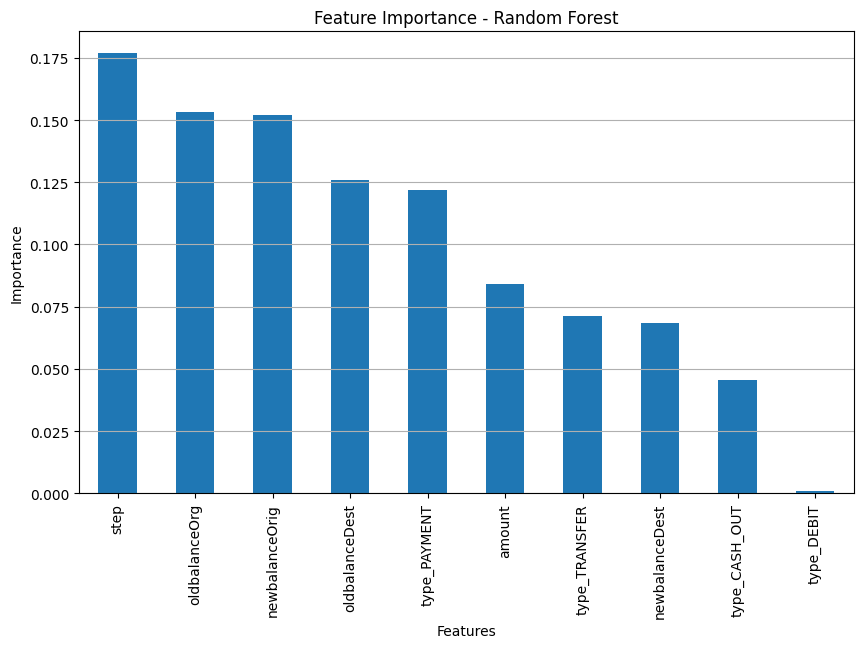

In [67]:
plt.figure(figsize=(10,6))

importance.plot(kind='bar')

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.grid(axis='y')

plt.show()